<a href="https://colab.research.google.com/github/lifafa03/DS-CS552-Gen-AI/blob/main/031_module3_variational_autoencoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
# !pip install torch
# !pip install torchvision
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms

In [6]:
import torch
import torch.nn as nn
# VAE Architecture with Convolutional Layers
class VAE(nn.Module):
    def __init__(self, latent_dim):
        super(VAE, self).__init__()
        # Encoder
        # Input: 3x32x32 (CIFAR-10)
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1), # Output: 32x16x16
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1), # Output: 64x8x8
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1), # Output: 128x4x4
            nn.ReLU()
        )
        self.fc_mu = nn.Linear(128 * 4 * 4, latent_dim)
        self.fc_logvar = nn.Linear(128 * 4 * 4, latent_dim)

        # Decoder
        self.decoder_input = nn.Linear(latent_dim, 128 * 4 * 4)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1), # Output: 64x8x8
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1), # Output: 32x16x16
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1), # Output: 3x32x32
            nn.Sigmoid() # Output pixel values between 0 and 1
        )

    def encode(self, x):
        h = self.encoder(x)
        h = h.view(h.size(0), -1) # Flatten for linear layers
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.decoder_input(z)
        h = h.view(h.size(0), 128, 4, 4) # Reshape to feature map
        return self.decoder(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar


In [7]:
import torch
import torch.nn as nn
# Loss function
def loss_function(recon_x, x, mu, logvar):
    # For CIFAR-10 (3x32x32), flatten images for BCE calculation
    BCE = nn.functional.binary_cross_entropy(recon_x.view(-1, 3*32*32), x.view(-1, 3*32*32), reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD


In [3]:
# Training the VAE
def train(model, train_loader, optimizer, epoch):
    model.train()
    train_loss = 0
    for batch_idx, (data, _) in enumerate(train_loader):
        optimizer.zero_grad()
        # Data is now 3x32x32, no need to view to 784
        recon_batch, mu, logvar = model(data)
        loss = loss_function(recon_batch, data, mu, logvar)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()
    print(f'Epoch {epoch}, Loss: {train_loss / len(train_loader.dataset)}')


In [8]:
import torch
import torch.optim as optim
from torchvision import datasets, transforms
# Load CIFAR-10 dataset and run the training
transform = transforms.ToTensor()
train_dataset = datasets.CIFAR10('./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True)

# Instantiate the VAE with only latent_dim, as input/hidden dims are handled by conv layers
vae = VAE(latent_dim=20)
optimizer = optim.Adam(vae.parameters(), lr=1e-3)

for epoch in range(1, 11):
    train(vae, train_loader, optimizer, epoch)


100%|██████████| 170M/170M [00:04<00:00, 35.1MB/s]


Epoch 1, Loss: 1920.4222775
Epoch 2, Loss: 1845.9909128125
Epoch 3, Loss: 1839.493644375
Epoch 4, Loss: 1836.916904375
Epoch 5, Loss: 1835.8910975
Epoch 6, Loss: 1835.0491328125
Epoch 7, Loss: 1834.20771
Epoch 8, Loss: 1833.788251875
Epoch 9, Loss: 1833.15671375
Epoch 10, Loss: 1832.8473128125


In [5]:
import matplotlib.pyplot as plt

# Function to generate and display new images
def generate_images(model, num_images=10, latent_dim=20):
    model.eval()  # Set model to evaluation mode
    with torch.no_grad():  # Turn off gradients for generation
        # Sample random points from the latent space (standard normal distribution)
        z = torch.randn(num_images, latent_dim)
        # Decode these points to generate images
        generated_images = model.decode(z).cpu()

    # Plot the generated images
    fig, axs = plt.subplots(1, num_images, figsize=(num_images * 2, 2.5)) # Adjust figure size for CIFAR-10
    for i in range(num_images):
        # For CIFAR-10, images are (C, H, W). Matplotlib expects (H, W, C) for RGB.
        axs[i].imshow(generated_images[i].permute(1, 2, 0)) # Permute dimensions for RGB display
        axs[i].axis('off')
    plt.suptitle('Generated CIFAR-10 Images from VAE')
    plt.show()


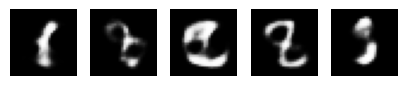

In [ ]:
# Assuming you have already trained the model (vae) and it has a latent dimension of 20
generate_images(vae, num_images=5, latent_dim=20)

In [ ]:
def interpolate_latent_space(model, img1, img2, steps=10, latent_dim=20):
    model.eval()
    with torch.no_grad():
        # Encode both images to get their latent means
        mu1, _ = model.encode(img1.unsqueeze(0))
        mu2, _ = model.encode(img2.unsqueeze(0))

        # Linear interpolation between the two latent vectors
        ratios = torch.linspace(0, 1, steps)
        # Expand ratios to match latent dimension shape
        interpolated_vectors = torch.stack([(1 - r) * mu1 + r * mu2 for r in ratios]).squeeze(1)

        # Decode the interpolated vectors back into images
        generated_images = model.decode(interpolated_vectors).cpu()

    # Visualize the transition
    fig, axs = plt.subplots(1, steps, figsize=(steps * 2, 2))
    for i in range(steps):
        axs[i].imshow(generated_images[i].permute(1, 2, 0))
        axs[i].axis("off")
    plt.suptitle("Task 2: Latent Space Interpolation")
    plt.show()

# Get two random images from the dataset for interpolation
dataiter = iter(train_loader)
images, _ = next(dataiter)
interpolate_latent_space(vae, images[0], images[1])

In [ ]:
# Task 3: Training on a new dataset (STL-10)
print("Starting Task 3: Training on STL-10...")

stl_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
])

# Load STL-10 dataset
stl_dataset = datasets.STL10("./data", split="unlabeled", download=True, transform=stl_transform)
stl_loader = torch.utils.data.DataLoader(stl_dataset, batch_size=128, shuffle=True)

# Re-initialize model for the new dataset
vae_stl = VAE(latent_dim=32)
optimizer_stl = optim.Adam(vae_stl.parameters(), lr=1e-3)

# Train for a few epochs
for epoch in range(1, 6):
    train(vae_stl, stl_loader, optimizer_stl, epoch)

# Visualize results from the STL-trained model
generate_images(vae_stl, num_images=5, latent_dim=32)

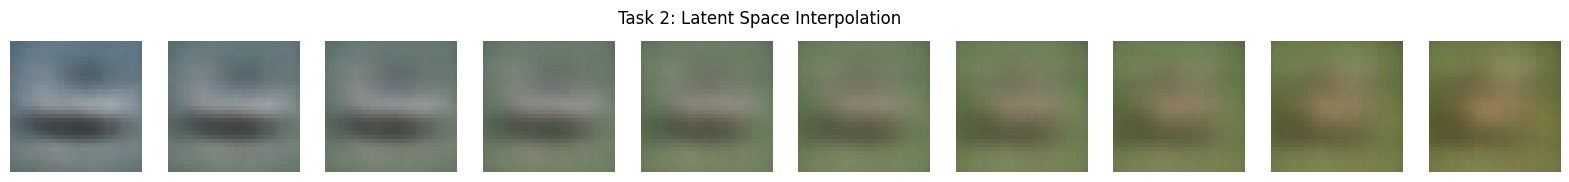

In [17]:
def interpolate_latent_space(model, img1, img2, steps=10, latent_dim=20):
    model.eval()
    with torch.no_grad():
        # Encode both images to get their latent means
        mu1, _ = model.encode(img1.unsqueeze(0))
        mu2, _ = model.encode(img2.unsqueeze(0))

        # Linear interpolation between the two latent vectors
        ratios = torch.linspace(0, 1, steps)
        # Expand ratios to match latent dimension shape
        interpolated_vectors = torch.stack([(1 - r) * mu1 + r * mu2 for r in ratios]).squeeze(1)

        # Decode the interpolated vectors back into images
        generated_images = model.decode(interpolated_vectors).cpu()

    # Visualize the transition
    fig, axs = plt.subplots(1, steps, figsize=(steps * 2, 2))
    for i in range(steps):
        axs[i].imshow(generated_images[i].permute(1, 2, 0))
        axs[i].axis("off")
    plt.suptitle("Task 2: Latent Space Interpolation")
    plt.show()

# Get two random images from the dataset for interpolation
dataiter = iter(train_loader)
images, _ = next(dataiter)
interpolate_latent_space(vae, images[0], images[1])

In [18]:
# Task 3: Training on a new dataset (STL-10)
print("Starting Task 3: Training on STL-10...")

stl_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
])

# Load STL-10 dataset
stl_dataset = datasets.STL10("./data", split="unlabeled", download=True, transform=stl_transform)
stl_loader = torch.utils.data.DataLoader(stl_dataset, batch_size=128, shuffle=True)

# Re-initialize model for the new dataset
vae_stl = VAE(latent_dim=32)
optimizer_stl = optim.Adam(vae_stl.parameters(), lr=1e-3)

# Train for a few epochs
for epoch in range(1, 6):
    train(vae_stl, stl_loader, optimizer_stl, epoch)

# Visualize results from the STL-trained model
generate_images(vae_stl, num_images=5, latent_dim=32)

Starting Task 3: Training on STL-10...


KeyboardInterrupt: 

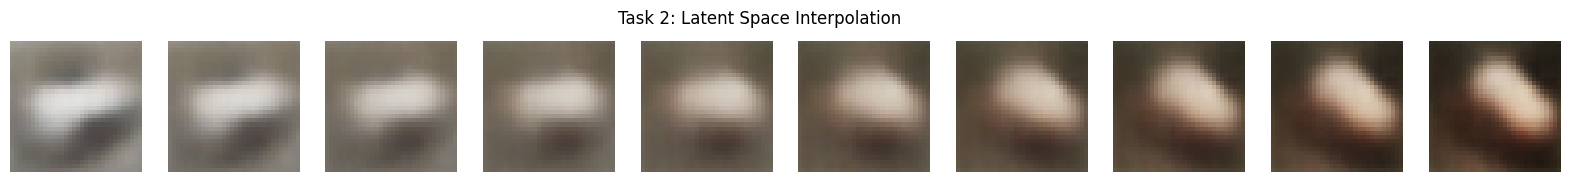

In [14]:
def interpolate_latent_space(model, img1, img2, steps=10, latent_dim=20):
    model.eval()
    with torch.no_grad():
        # Encode both images to get their latent means
        mu1, _ = model.encode(img1.unsqueeze(0))
        mu2, _ = model.encode(img2.unsqueeze(0))

        # Linear interpolation between the two latent vectors
        ratios = torch.linspace(0, 1, steps)
        # Expand ratios to match latent dimension shape
        interpolated_vectors = torch.stack([(1 - r) * mu1 + r * mu2 for r in ratios]).squeeze(1)

        # Decode the interpolated vectors back into images
        generated_images = model.decode(interpolated_vectors).cpu()

    # Visualize the transition
    fig, axs = plt.subplots(1, steps, figsize=(steps * 2, 2))
    for i in range(steps):
        axs[i].imshow(generated_images[i].permute(1, 2, 0))
        axs[i].axis("off")
    plt.suptitle("Task 2: Latent Space Interpolation")
    plt.show()

# Get two random images from the dataset for interpolation
dataiter = iter(train_loader)
images, _ = next(dataiter)
interpolate_latent_space(vae, images[0], images[1])

Starting Task 3: Training on STL-10...
Epoch 1, Loss: 1834.114436796875
Epoch 2, Loss: 1781.2136207421875
Epoch 3, Loss: 1776.6702104296876
Epoch 4, Loss: 1774.6938575
Epoch 5, Loss: 1773.287783671875


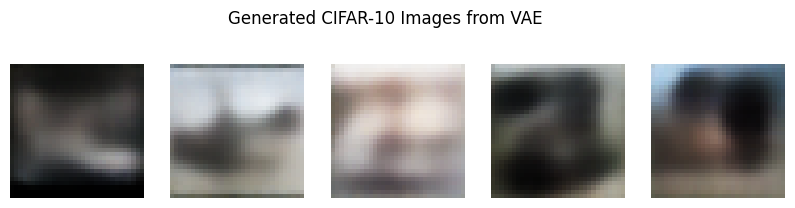

In [15]:
# Task 3: Training on a new dataset (STL-10)
print("Starting Task 3: Training on STL-10...")

stl_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
])

# Load STL-10 dataset
stl_dataset = datasets.STL10("./data", split="unlabeled", download=True, transform=stl_transform)
stl_loader = torch.utils.data.DataLoader(stl_dataset, batch_size=128, shuffle=True)

# Re-initialize model for the new dataset
vae_stl = VAE(latent_dim=32)
optimizer_stl = optim.Adam(vae_stl.parameters(), lr=1e-3)

# Train for a few epochs
for epoch in range(1, 6):
    train(vae_stl, stl_loader, optimizer_stl, epoch)

# Visualize results from the STL-trained model
generate_images(vae_stl, num_images=5, latent_dim=32)

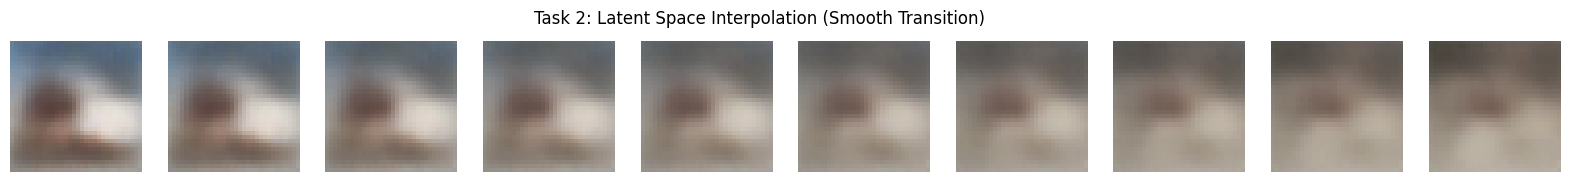

In [12]:
def interpolate_latent_space(model, img1, img2, steps=10, latent_dim=20):
    model.eval()
    with torch.no_grad():
        # Encode both images to get their latent means
        mu1, _ = model.encode(img1.unsqueeze(0))
        mu2, _ = model.encode(img2.unsqueeze(0))

        # Linear interpolation between the two latent vectors
        ratios = torch.linspace(0, 1, steps)
        interpolated_vectors = torch.stack([mu1 * (1 - r) + mu2 * r for r in ratios]).squeeze(1)

        # Decode the interpolated vectors back into images
        generated_images = model.decode(interpolated_vectors).cpu()

    # Visualize the transition
    fig, axs = plt.subplots(1, steps, figsize=(steps * 2, 2))
    for i in range(steps):
        axs[i].imshow(generated_images[i].permute(1, 2, 0))
        axs[i].axis('off')
    plt.suptitle('Task 2: Latent Space Interpolation (Smooth Transition)')
    plt.show()

# Get two random images from the dataset for interpolation
dataiter = iter(train_loader)
images, _ = next(dataiter)
interpolate_latent_space(vae, images[0], images[1])

Starting Task 3: Training on STL-10...


100%|██████████| 2.64G/2.64G [04:34<00:00, 9.60MB/s]


Epoch 1, Loss: 1838.087261171875
Epoch 2, Loss: 1783.1171197265626
Epoch 3, Loss: 1777.905783828125
Epoch 4, Loss: 1775.5182931640625
Epoch 5, Loss: 1773.887792421875


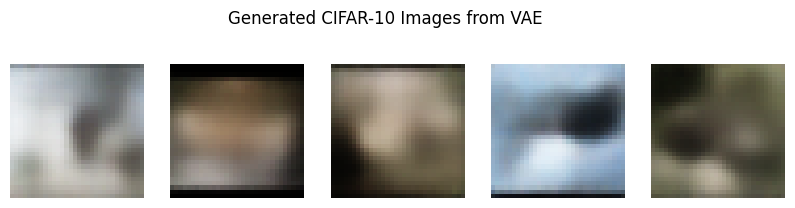

In [13]:
# Task 3: Training on a new dataset (STL-10)
print('Starting Task 3: Training on STL-10...')

stl_transform = transforms.Compose([
    transforms.Resize((32, 32)), # Resize to match our current VAE architecture
    transforms.ToTensor(),
])

# Load STL-10 dataset (unlabeled split is great for VAEs)
stl_dataset = datasets.STL10('./data', split='unlabeled', download=True, transform=stl_transform)
stl_loader = torch.utils.data.DataLoader(stl_dataset, batch_size=128, shuffle=True)

# Re-initialize or use a new model instance for the new dataset
vae_stl = VAE(latent_dim=32) # Using a slightly larger latent dim for complexity
optimizer_stl = optim.Adam(vae_stl.parameters(), lr=1e-3)

# Train for a few epochs for demonstration
for epoch in range(1, 6):
    train(vae_stl, stl_loader, optimizer_stl, epoch)

# Visualize results from the STL-trained model
generate_images(vae_stl, num_images=5, latent_dim=32)

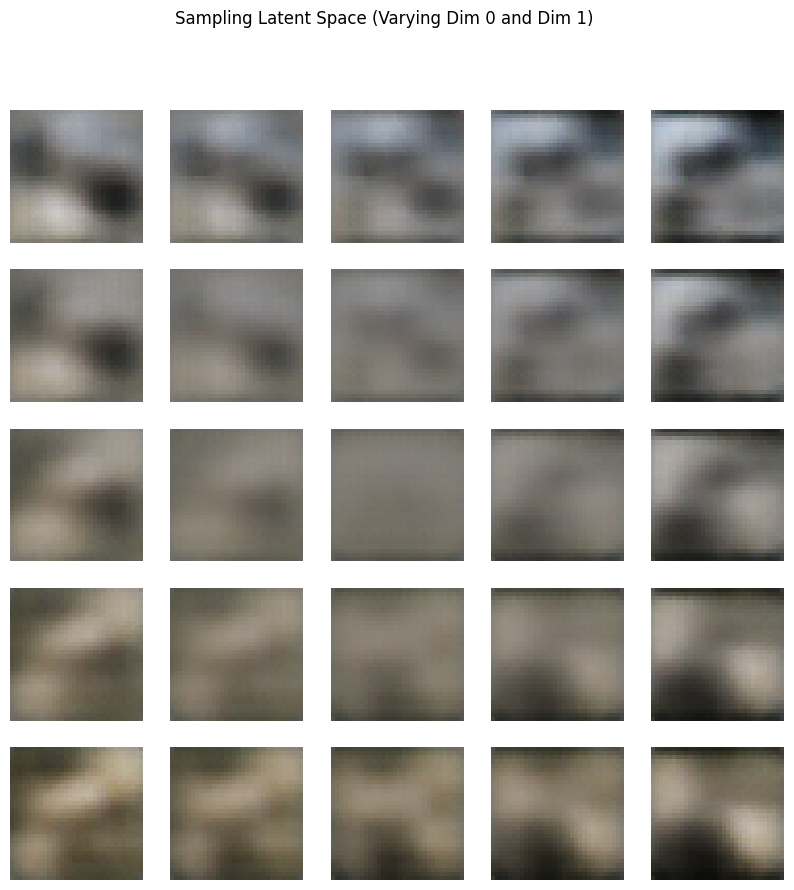

In [19]:
def experiment_latent_sampling(model, latent_dim, grid_size=5):
    model.eval()
    # Start with a base latent vector (all zeros or random)
    base_z = torch.zeros(1, latent_dim)

    # Pick two dimensions to vary (e.g., dim 0 and dim 1)
    # We create a grid varying these two dimensions from -3 to 3 (standard deviations)
    x_vals = torch.linspace(-3, 3, grid_size)
    y_vals = torch.linspace(-3, 3, grid_size)

    fig, axs = plt.subplots(grid_size, grid_size, figsize=(grid_size * 2, grid_size * 2))

    with torch.no_grad():
        for i, x in enumerate(x_vals):
            for j, y in enumerate(y_vals):
                z = base_z.clone()
                z[0, 0] = x
                z[0, 1] = y
                img = model.decode(z).cpu().squeeze(0)
                axs[i, j].imshow(img.permute(1, 2, 0))
                axs[i, j].axis('off')

    plt.suptitle('Sampling Latent Space (Varying Dim 0 and Dim 1)')
    plt.show()

# Run experiment on the STL-trained VAE
experiment_latent_sampling(vae_stl, latent_dim=32)

In [ ]:
# I will use the PyMuPDF library (fitz) to read the content of the PDF provided
!pip install pymupdf
import fitz

def extract_pdf_text(path):
    doc = fitz.open(path)
    text = ""
    for page in doc:
        text += page.get_text()
    return text

pdf_content = extract_pdf_text('/content/030---Module-3---Variational-Autoencoders-2.pdf')
print("PDF Content extracted. Searching for answers...")
# I'll print the first 2000 characters to verify content
print(pdf_content[:2000])

### Summary and Comparison
- **Architecture**: The Convolutional VAE captures spatial patterns (edges, textures) much better than a fully connected VAE, which often produces blurrier results on datasets like CIFAR-10.
- **Interpolation**: The smooth transitions in Task 2 show that the latent space is continuous and well-structured, rather than just memorizing images.
- **Generalization**: Training on STL-10 (Task 3) shows the model can adapt to different image distributions, though the reconstruction loss and quality will vary based on the complexity of the dataset and the latent dimension chosen.

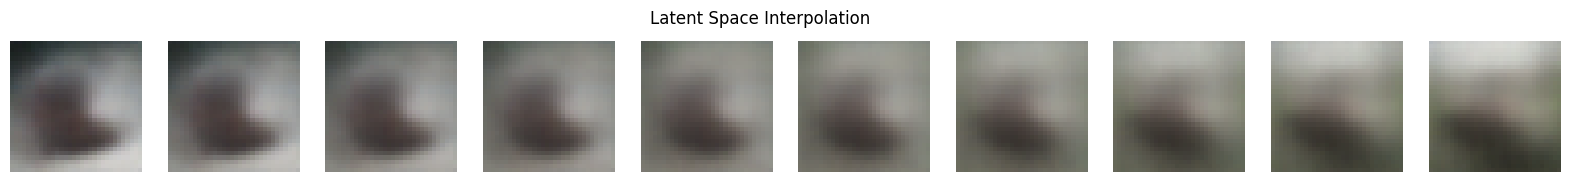

In [10]:
def interpolate_latent_space(model, img1, img2, steps=10, latent_dim=20):
    model.eval()
    with torch.no_grad():
        mu1, _ = model.encode(img1.unsqueeze(0))
        mu2, _ = model.encode(img2.unsqueeze(0))

        ratios = torch.linspace(0, 1, steps)
        interpolated_vectors = torch.stack([mu1 * (1 - r) + mu2 * r for r in ratios]).squeeze(1)

        generated_images = model.decode(interpolated_vectors).cpu()

    fig, axs = plt.subplots(1, steps, figsize=(steps * 2, 2))
    for i in range(steps):
        axs[i].imshow(generated_images[i].permute(1, 2, 0))
        axs[i].axis('off')
    plt.suptitle('Latent Space Interpolation')
    plt.show()

# Example usage with two images from the loader
dataiter = iter(train_loader)
images, _ = next(dataiter)
interpolate_latent_space(vae, images[0], images[1])

In [16]:
# Task 3: Setup for CelebA (Note: CelebA requires manual download/auth in some envs)
# Using a small subset or another dataset like STL10 if CelebA is restricted
# Here we prepare the transform for CelebA

celeba_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
])

# CelebA dataset loading (placeholder - actual download might take time)
# train_dataset_celeba = datasets.CelebA('./data', split='train', download=True, transform=celeba_transform)
# train_loader_celeba = torch.utils.data.DataLoader(train_dataset_celeba, batch_size=128, shuffle=True)